✅ Máscara salva: dataset/masks/img20250313_10443025.png


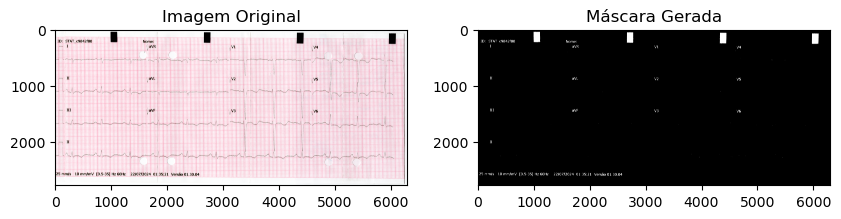

🎉 Fim do processo! Todas as máscaras foram geradas.


In [1]:
# 📒 Notebook: Geração automática de máscaras para ECG com fundo quadriculado

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# 📁 1. Caminhos de entrada e saída
input_dir = 'dataset/images'       # ECGs com linha azul ou preta
output_dir = 'dataset/masks'       # Máscaras binárias geradas
os.makedirs(output_dir, exist_ok=True)

# ---------------------------------------------------
# 🧠 2. Função para detectar linhas com base em cor

def gerar_mascara_ecg(path_img):
    img = cv2.imread(path_img)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # 🎯 Detectar linha azul (ajuste tons conforme necessário)
    lower_blue = np.array([90, 50, 50])
    upper_blue = np.array([130, 255, 255])
    mask_blue = cv2.inRange(hsv, lower_blue, upper_blue)

    # 🎯 Detectar linha preta (por limiarização simples em tons de cinza)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, mask_black = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY_INV)

    # 📌 Combinar as duas (linha azul OU preta)
    combined_mask = cv2.bitwise_or(mask_blue, mask_black)

    # 🪄 Limpeza opcional (remover ruídos pequenos)
    kernel = np.ones((3,3), np.uint8)
    clean_mask = cv2.morphologyEx(combined_mask, cv2.MORPH_OPEN, kernel)

    return clean_mask

# ---------------------------------------------------
# 🚀 3. Rodar para todas as imagens do dataset
arquivos = [f for f in os.listdir(input_dir) if f.lower().endswith(('.png', '.jpg'))]

for nome in arquivos:
    caminho = os.path.join(input_dir, nome)
    mask = gerar_mascara_ecg(caminho)
    saida = os.path.join(output_dir, nome)
    cv2.imwrite(saida, mask)
    print(f"✅ Máscara salva: {saida}")

# ---------------------------------------------------
# 📊 4. Visualizar exemplo
exemplo = arquivos[0]
img = cv2.imread(os.path.join(input_dir, exemplo))
mask = cv2.imread(os.path.join(output_dir, exemplo), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.title('Imagem Original'); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.subplot(1,2,2); plt.title('Máscara Gerada'); plt.imshow(mask, cmap='gray')
plt.show()

print("🎉 Fim do processo! Todas as máscaras foram geradas.")
